# FAPE, Folktables ACS Stage 2: ThresholdOptimizer

Phase 4, Stage 2 fairness intervention in the socioeconomic domain. The script applies Fairlearn's ThresholdOptimizer post-processing to the Folktables ACS baseline models under the demographic parity and equalized odds constraints, with RAC1P (race, 9 groups) as the sensitive attribute for both and a separate demographic parity run on SEX for reference. The label is personal income (PINCP) above $50,000. The family income-to-poverty ratio is not a model feature, because family income contains the person's own income and would hand the model most of the label. Race-level rates and the DIR against White are computed for groups with at least 30 test records; two race groups fall under that floor, and the DPD and EOD values over all groups are sensitive to them (see `group_size_check.py`). ThresholdOptimizer.predict is seeded (random_state=42), so runs are repeatable.

Code: `src/stage2_folktables_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_folktables_threshold import run_stage2

run_stage2()

FAPE Phase 4 - Folktables ACS Stage 2: ThresholdOptimizer
Loading Folktables ACS data, first run downloads per state, please wait...


  AL: 22,161 records
  AK: 3,225 records


  AZ: 33,766 records


  AR: 13,364 records


  CA: 189,413 records


...

  White                n=13,360 true=0.467 base=0.462 constrained=0.471
  Black                n=1,584 true=0.299 base=0.333 constrained=0.391
  Am.Indian            n=  214 true=0.285 base=0.280 constrained=0.472
  Asian                n=1,338 true=0.516 base=0.496 constrained=0.497
  Pacific Islander     n=   33 true=0.364 base=0.333 constrained=0.485
  Other                n=1,243 true=0.237 base=0.193 constrained=0.376
  Two or more          n=2,198 true=0.345 base=0.323 constrained=0.433
  Black-White base gap: -0.129
  Black-White constrained gap: -0.080

--- DIR against White, GB Before vs After EO Constraint (groups with n>=30) ---
  Black                n=1,584 DIR 0.72 -> 0.83
  Am.Indian            n=  214 DIR 0.61 -> 1.00
  Asian                n=1,338 DIR 1.07 -> 1.05
  Pacific Islander     n=   33 DIR 0.72 -> 1.03
  Other                n=1,243 DIR 0.42 -> 0.80
  Two or more          n=2,198 DIR 0.70 -> 0.92

--- FPR/FNR by Race - GB Before vs After EO Constraint ---
  Bl

Fig 2 saved - folktables_fairness_improvement.png
Fig 3 saved - folktables_cost_gain_scatter.png
Fig 4 saved - folktables_sex_fairness.png


Fig 5 saved - folktables_f1_comparison.png
Fig 6 saved - folktables_race_prediction_rates.png


Fig 7 saved - folktables_fpr_fnr_by_race.png
Fig 8 saved - folktables_dir_by_race.png


Fig 9 saved - folktables_dir_before_after.png

--- Folktables Stage 2 complete ---
  9 figures saved to figures/stage2/


## 1. Accuracy and DPD, baseline and constrained

Accuracy and race demographic parity difference for each model at baseline and under each constraint.

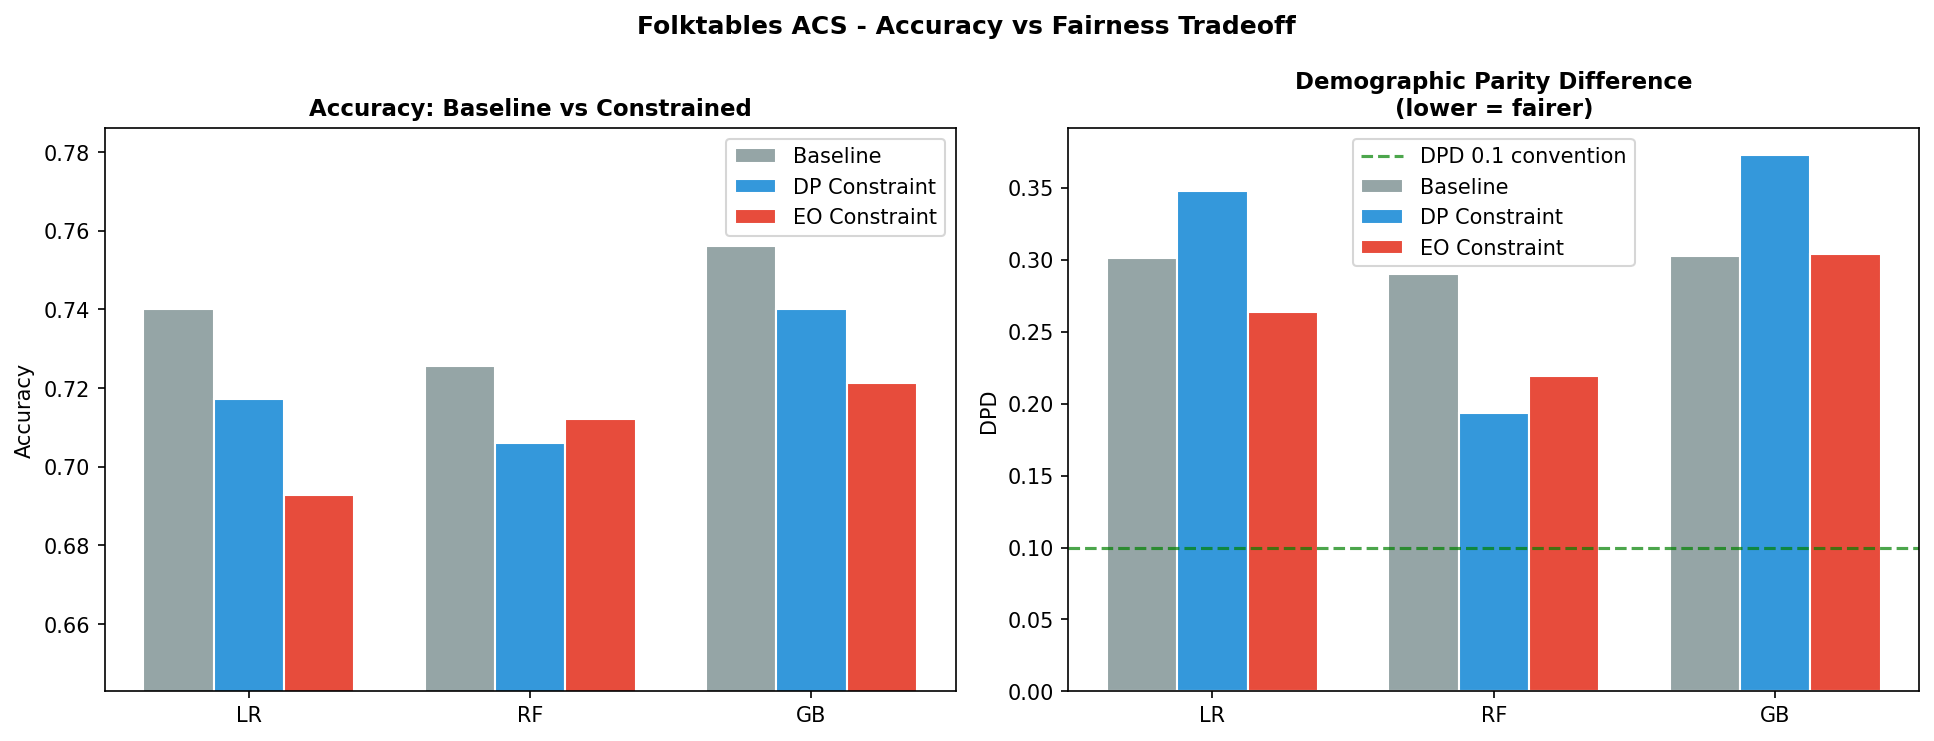

In [3]:
display(Image('figures/stage2/folktables_accuracy_fairness_tradeoff.png'))

## 2. DPD and EOD by constraint

Race DPD before and after the demographic parity constraint, and race EOD before and after the equalized odds constraint.

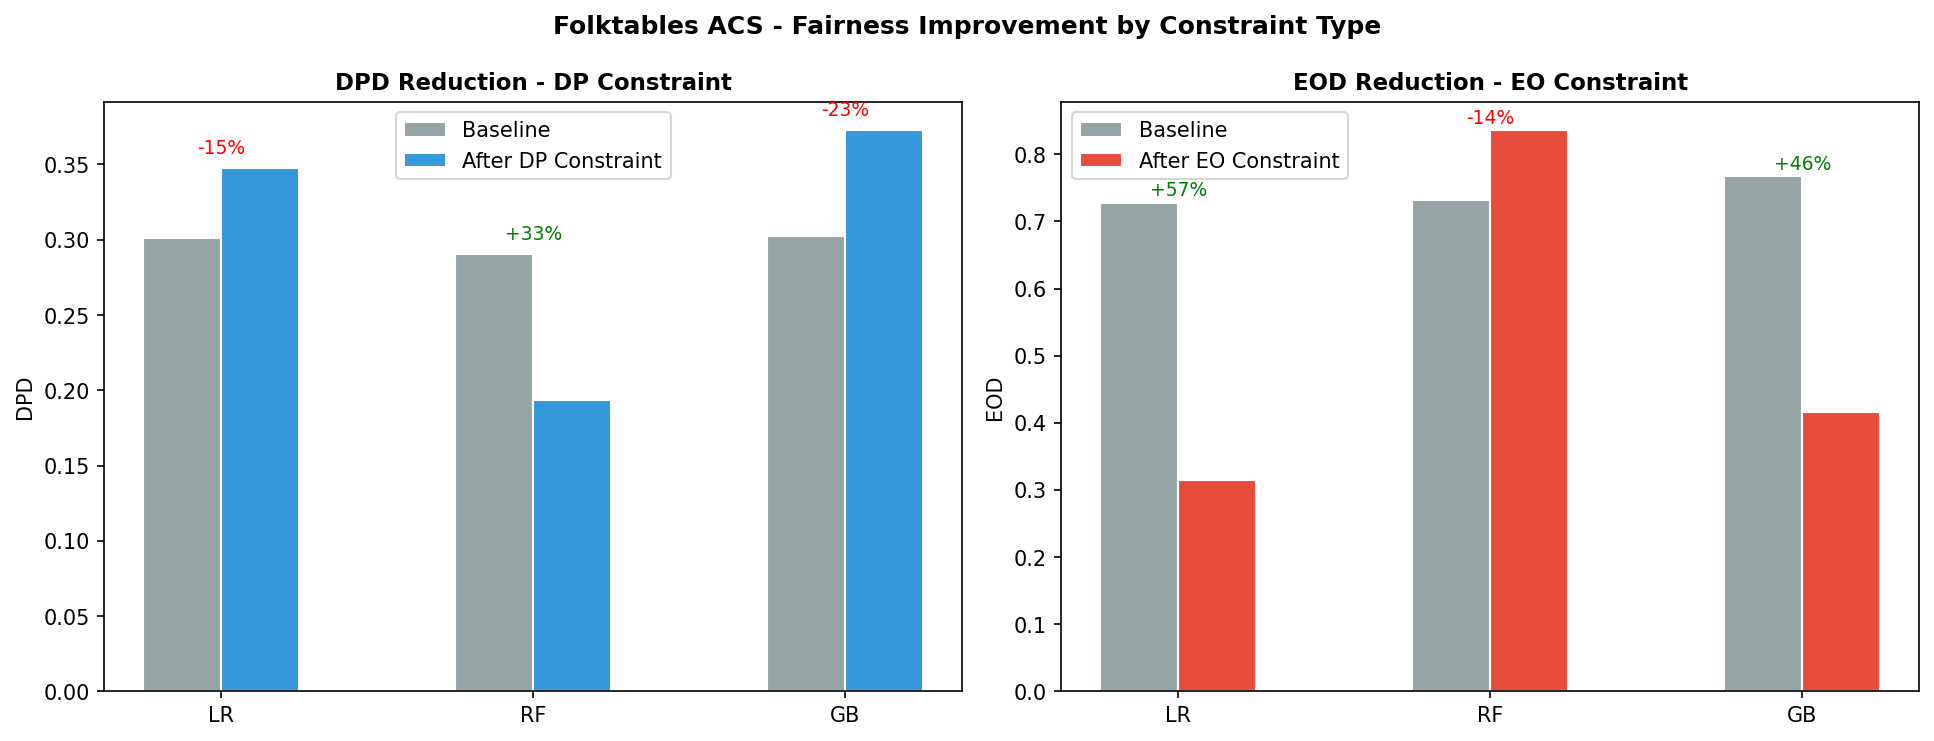

In [4]:
display(Image('figures/stage2/folktables_fairness_improvement.png'))

## 3. Accuracy cost against fairness gain

Each model's accuracy cost plotted against its fairness gain under each constraint.

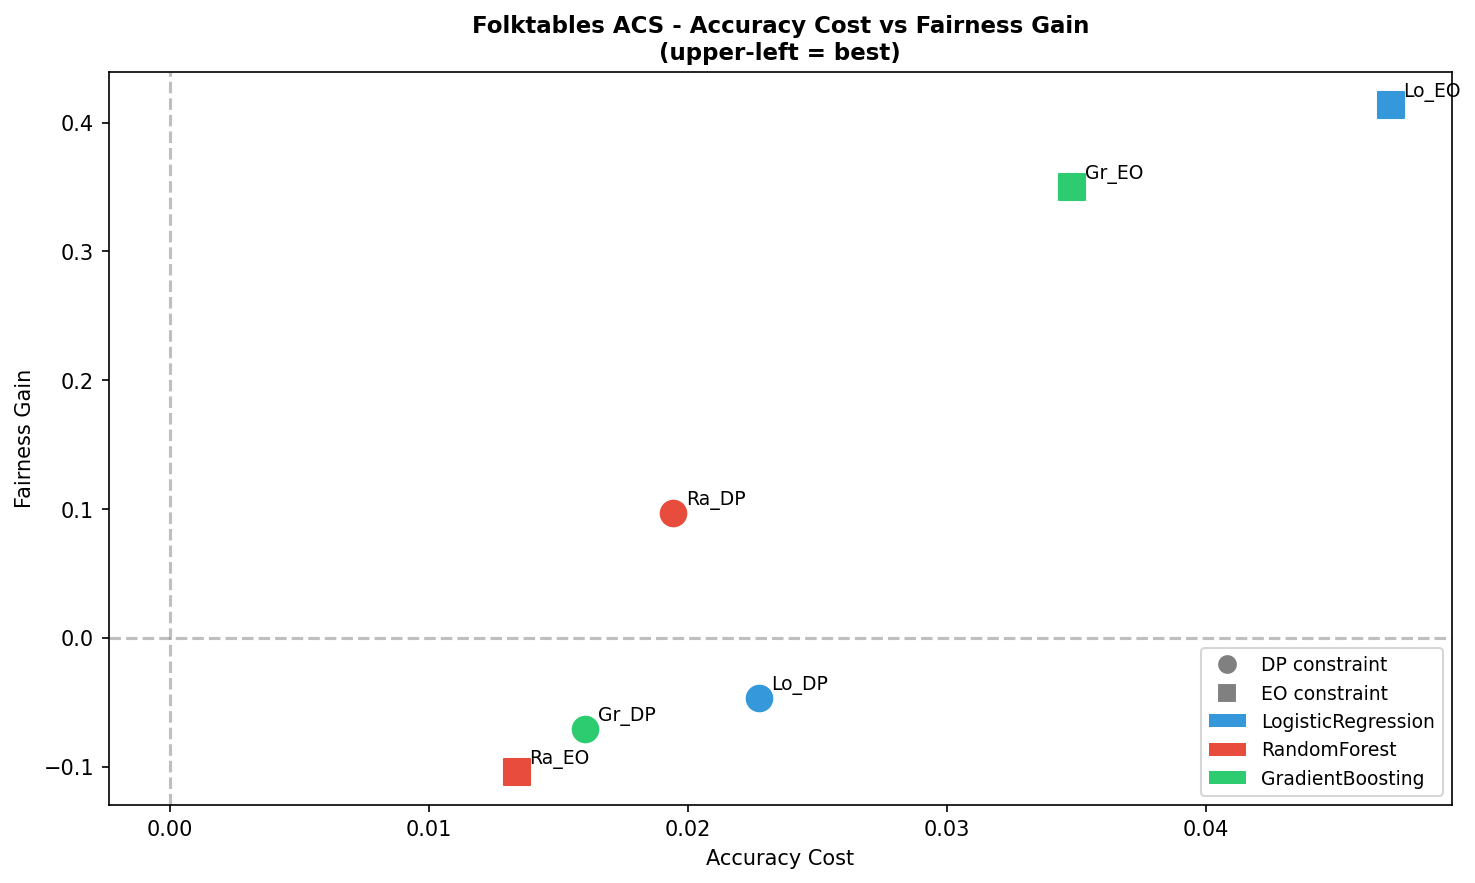

In [5]:
display(Image('figures/stage2/folktables_cost_gain_scatter.png'))

## 4. Sex fairness under a constraint on sex

Sex DPD and EOD for each model after the demographic parity constraint is applied on sex.

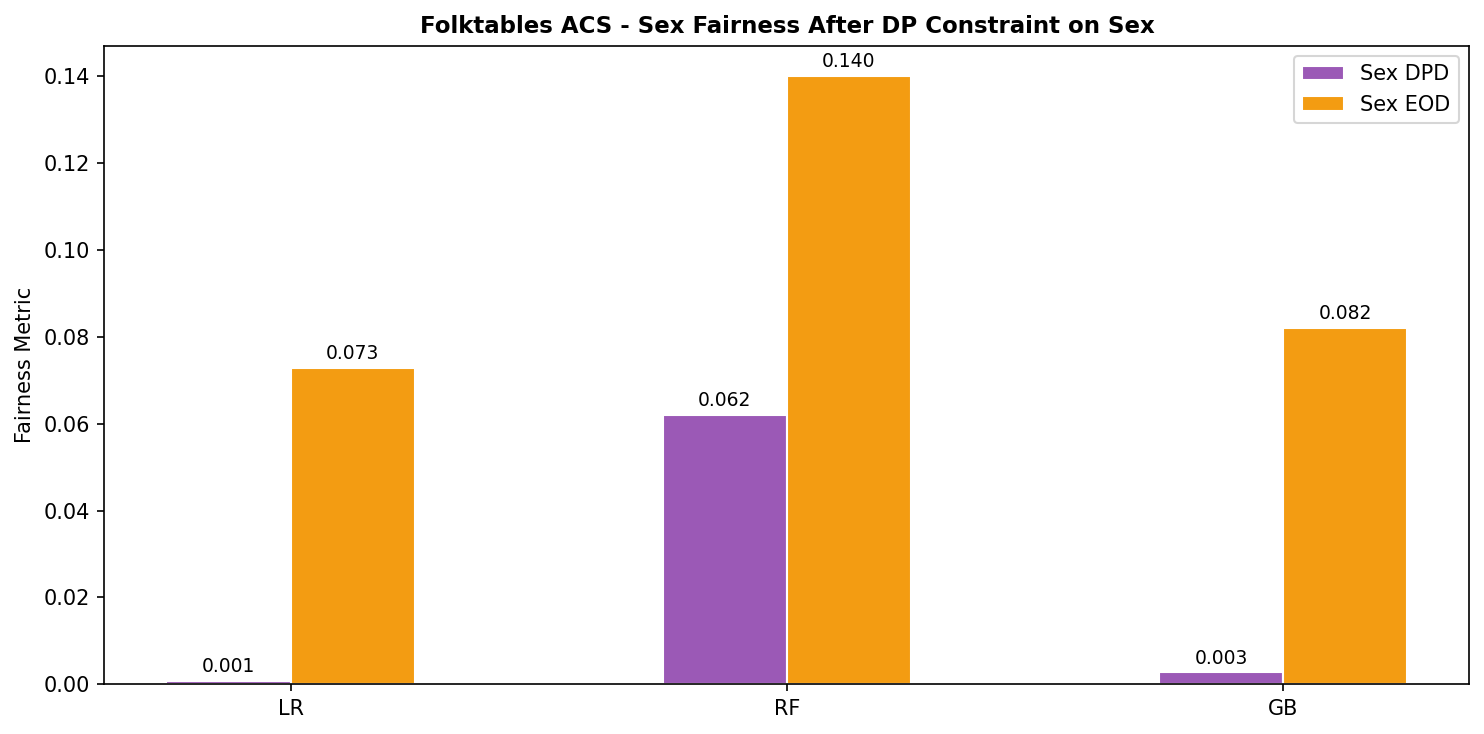

In [6]:
display(Image('figures/stage2/folktables_sex_fairness.png'))

## 5. F1 comparison

F1 score for each model at baseline and under each constraint.

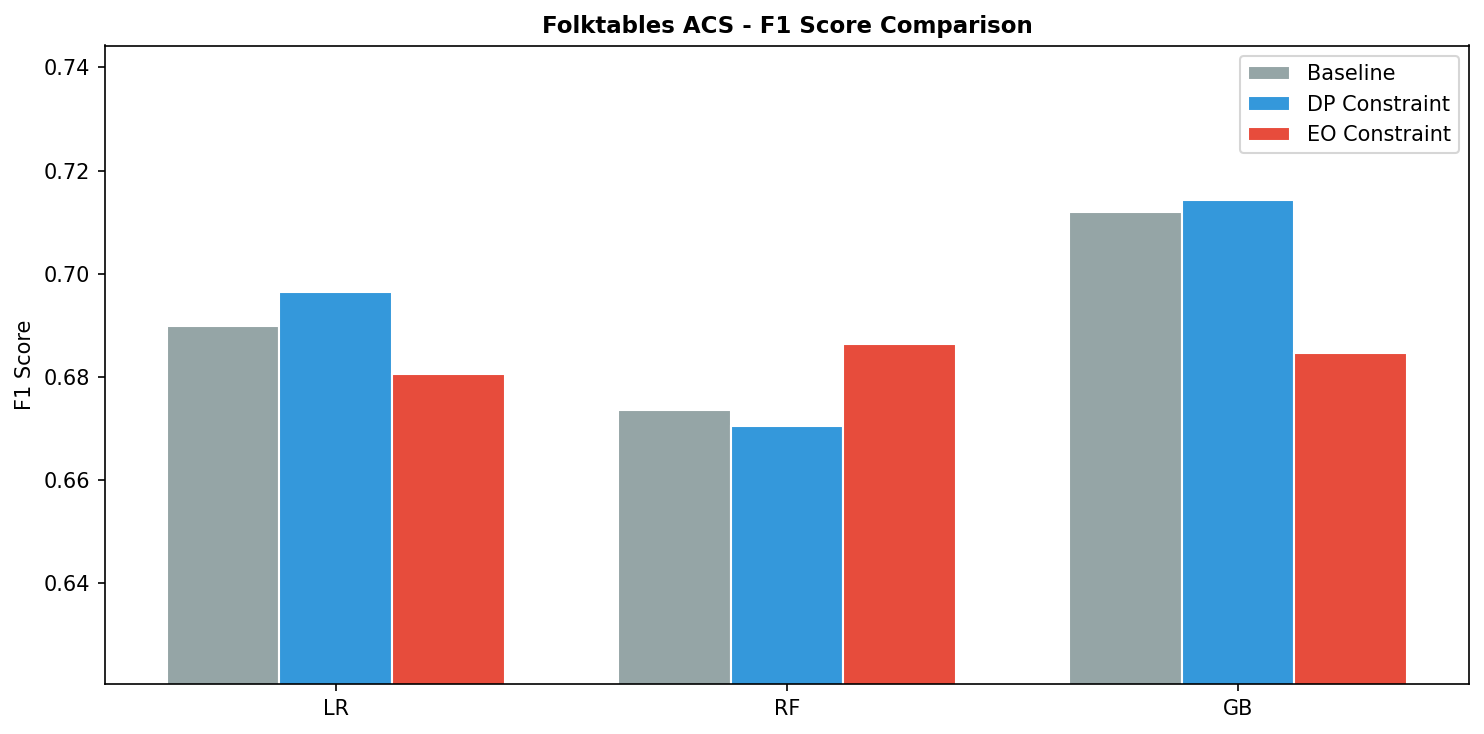

In [7]:
display(Image('figures/stage2/folktables_f1_comparison.png'))

## 6. Predicted rates by race

True and predicted positive rates by race for gradient boosting, at baseline and under the equalized odds constraint.

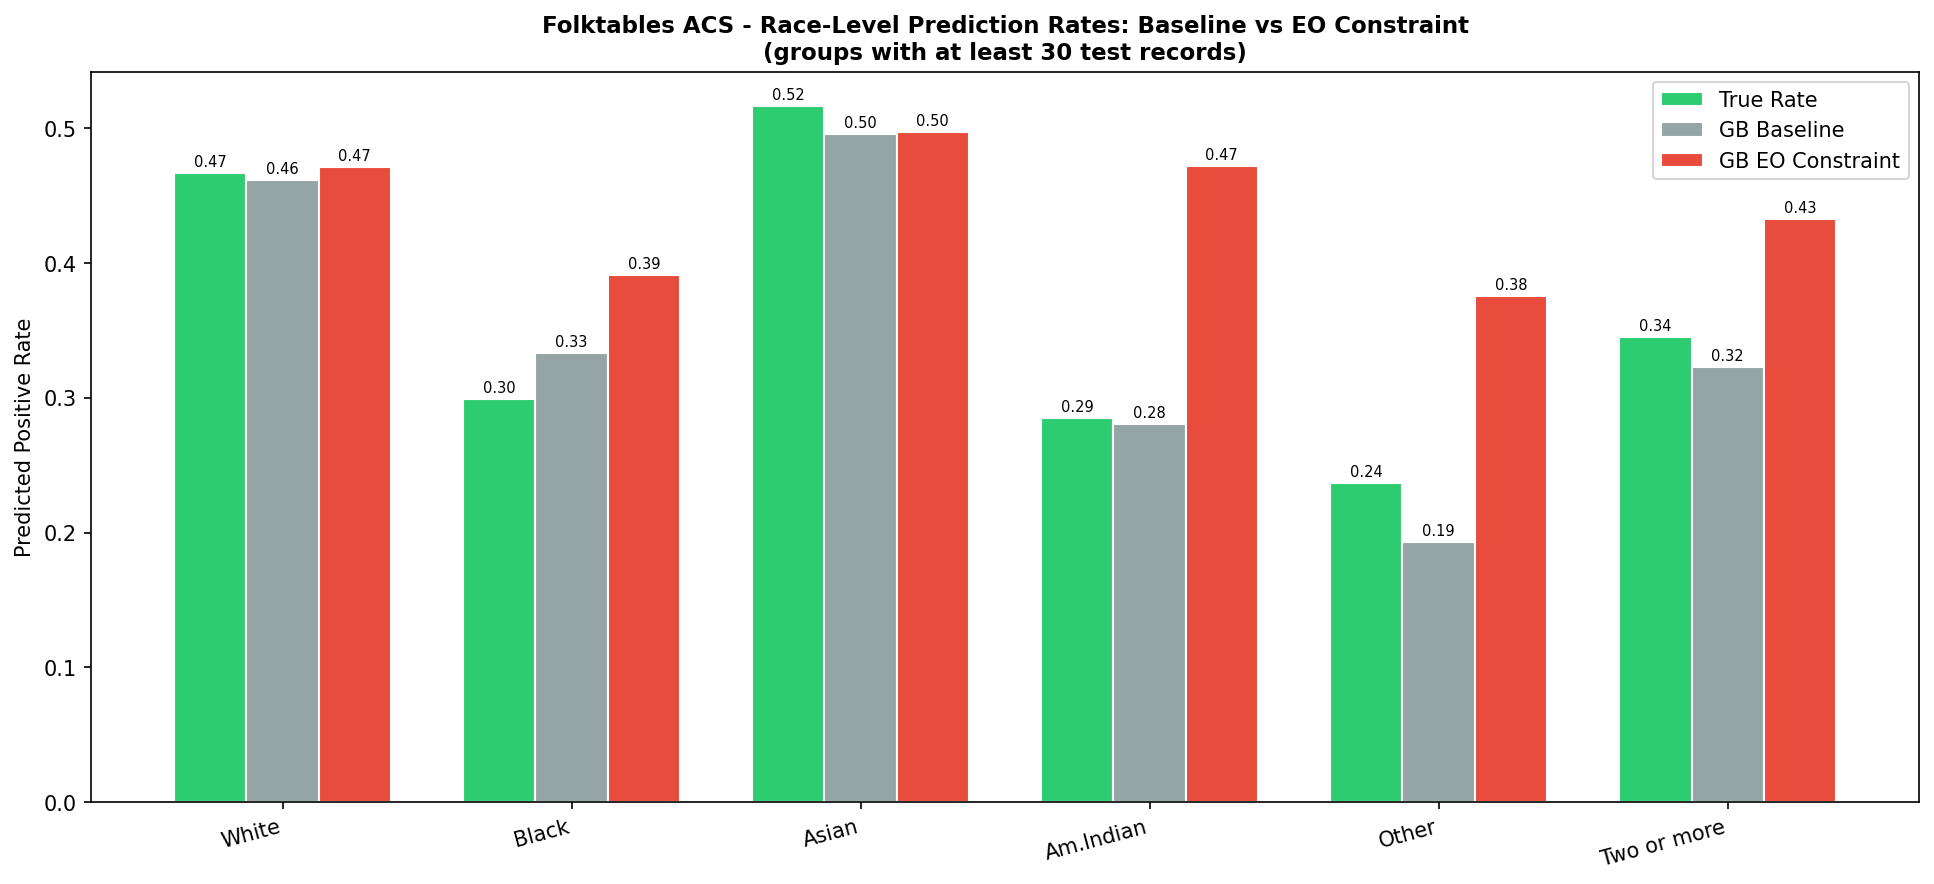

In [8]:
display(Image('figures/stage2/folktables_race_prediction_rates.png'))

## 7. FPR and FNR by race

Gradient boosting's false positive and false negative rates by race, at baseline and under the equalized odds constraint.

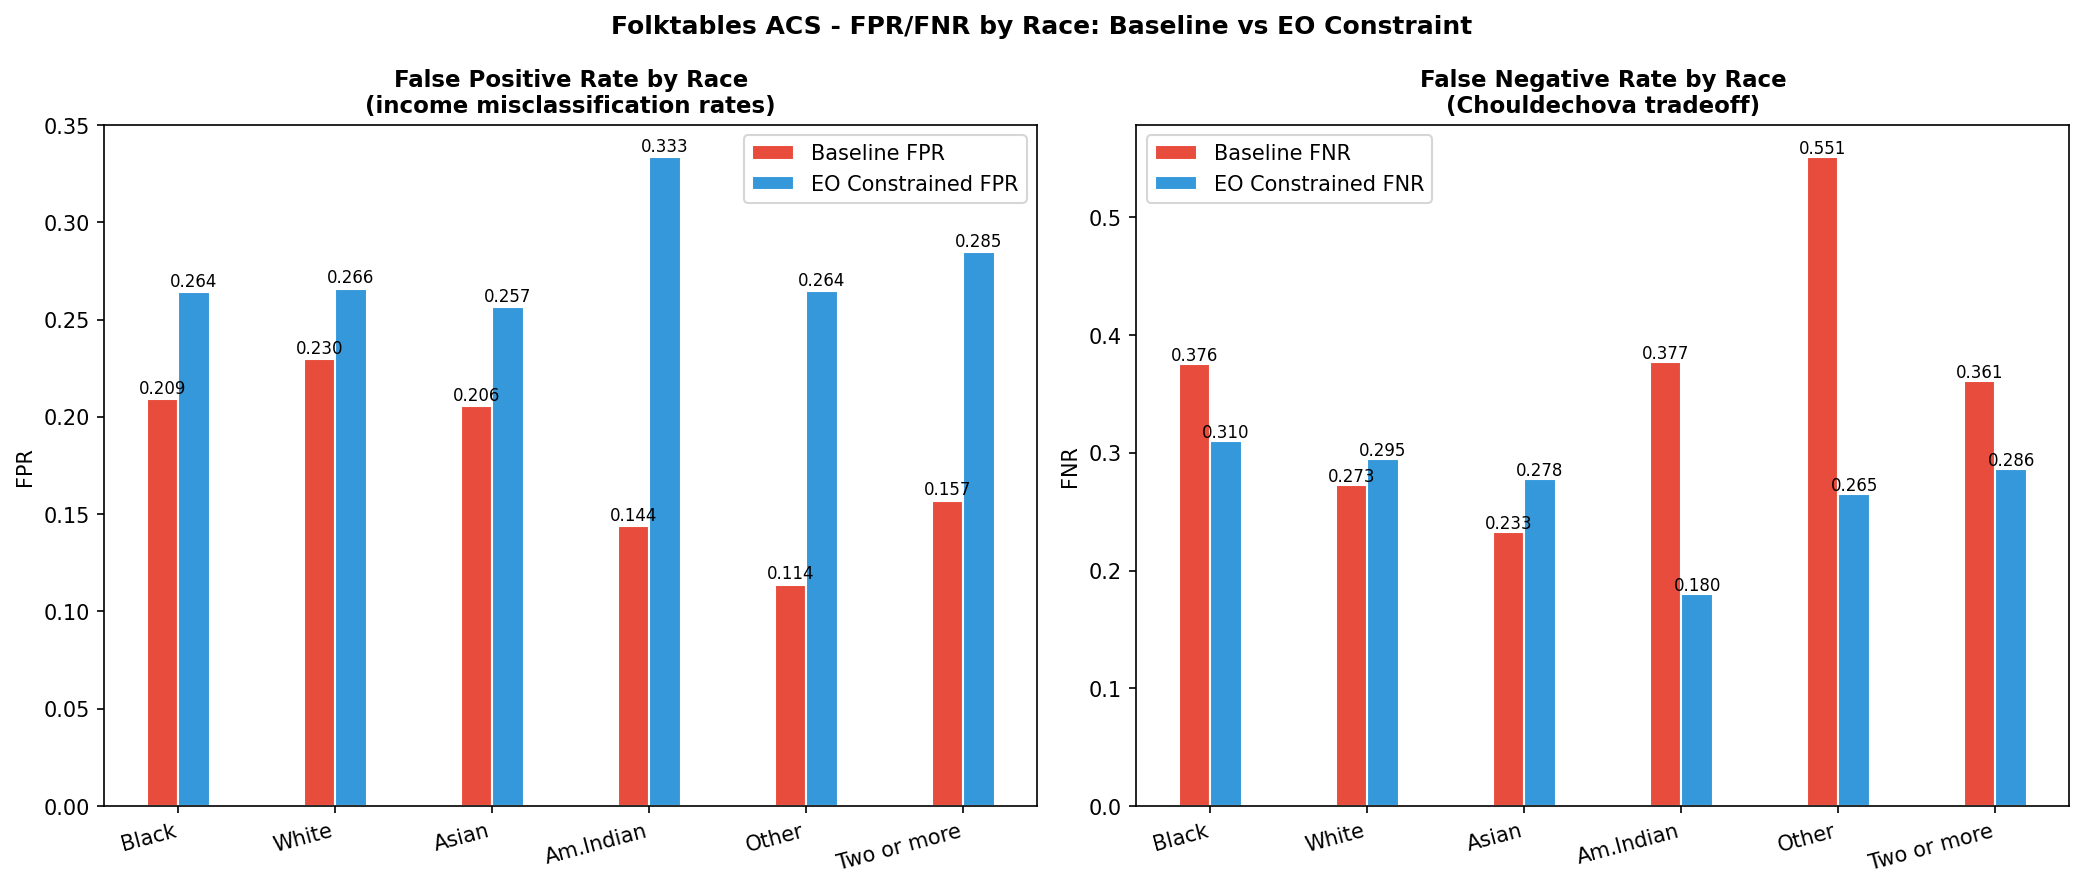

In [9]:
display(Image('figures/stage2/folktables_fpr_fnr_by_race.png'))

## 8. Disparate impact ratio by race, baseline

Each race group's predicted positive rate relative to White for the gradient boosting baseline.

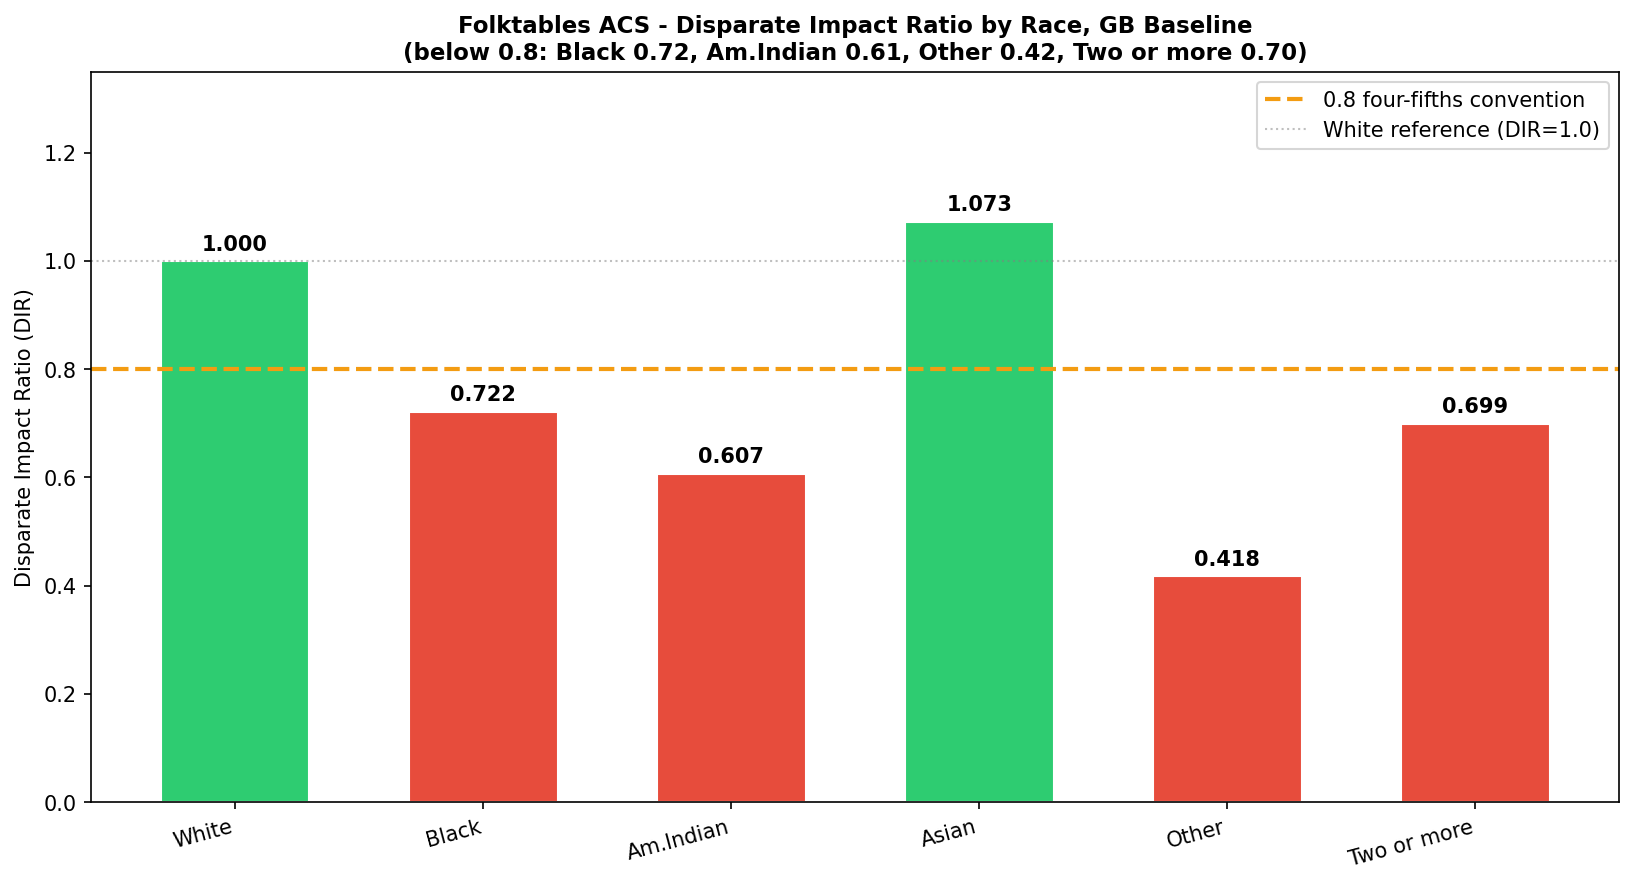

In [10]:
display(Image('figures/stage2/folktables_dir_by_race.png'))

## 9. Disparate impact ratio before and after the equalized odds constraint

Each race group's ratio to White for gradient boosting, before and after the equalized odds constraint.

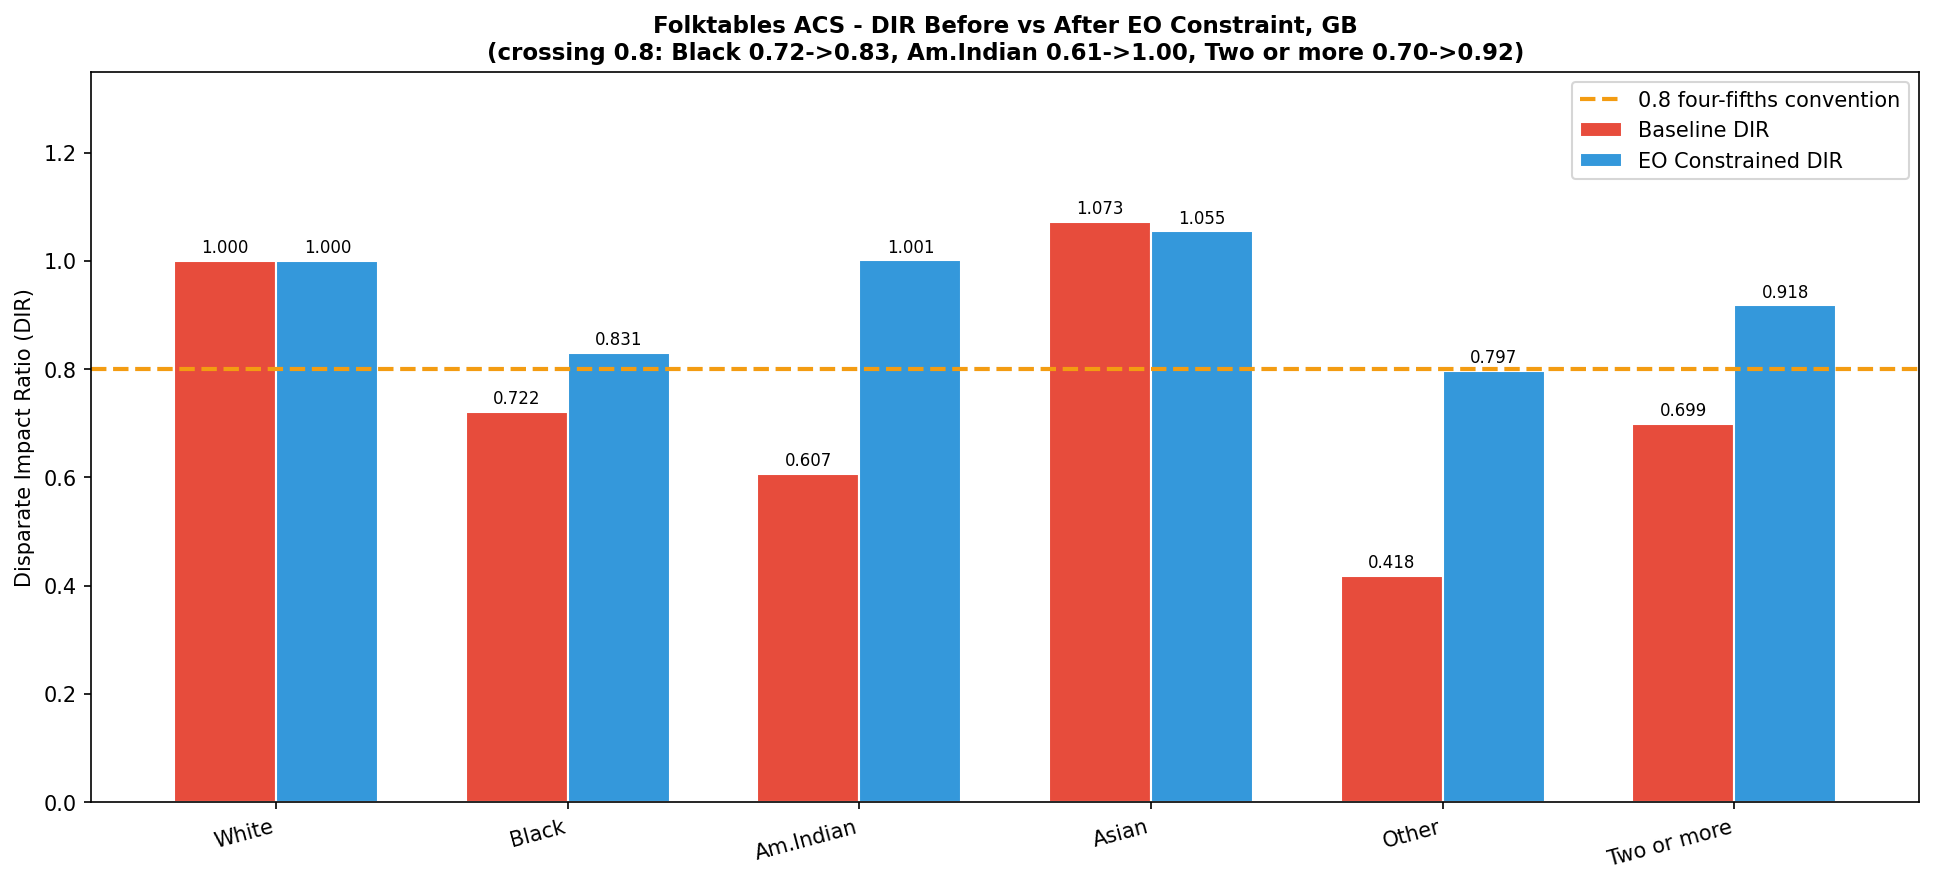

In [11]:
display(Image('figures/stage2/folktables_dir_before_after.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.